#**Assignment (WC #2 EDA & Data Preprocessing)**
##Tips Pengerjaan :

1. Klik file > save a copy in drive untuk menyalin notebook ini
2. Kerjakan soal di placeholder yang sudah ditentukan
3. Coba untuk tidak menggunakan AI dulu, pelajari materi yang sudah diberikan
4. Rename file notebook dengan format "WC#2_Nama_Group", contoh "WC#2_Rifan Nashir_Group 3" dan dengan format ".ipynb"

---

**Main References:**

Library Docummentation:
- Pandas https://pandas.pydata.org/docs/
- Numpy https://numpy.org/doc/stable/
- Matplotlib https://matplotlib.org/stable/gallery/index.html
- Seaborn https://seaborn.pydata.org/tutorial.html

EDA:
- www.geeksforgeeks.org/data-analysis/what-is-exploratory-data-analysis

Level of Analysis:
- https://www.youtube.com/watch?v=gN0OQ6r78f4

Data Preprocessing:
- www.geeksforgeeks.org/data-science/data-preprocessing-in-data-mining
- https://youtu.be/FPvMBl8LvGA?si=IO-j79eGYbswrEaM

# 🎯 Tugas: Exploratory Data Analysis (EDA) & Data Preprocessing

###Selamat datang di tugas mandiri EDA dan Preprocessing! Pada tugas ini, kamu akan mempraktikkan cara mengolah data mentah menjadi data yang bersih dan siap digunakan untuk pemodelan Machine Learning.

**Instruksi:**
1. Tambahkan **Code Cell** di bawah setiap poin instruksi untuk menuliskan kodemu.
2. Tambahkan **Text Cell** jika diminta untuk menuliskan interpretasi atau kesimpulan.
3. Jangan lupa import library `pandas dan numpy`,  dan library visualisasi yang kamu butuhkan (seperti `matplotlib.pyplot` atau `seaborn`) di awal.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 📂 1. Load Data
Muat dataset yang telah diberikan menggunakan pustaka Pandas.
* **Tugas:** Gunakan `pd.read_csv()` untuk memuat data ke dalam variabel DataFrame (misalnya `df`), lalu tampilkan datanya.

In [5]:
df = pd.read_csv('Student_Performance_Tugas.csv')

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99.0,Yes,9.0,1,91.0
1,4,82.0,No,4.0,2,65.0
2,8,51.0,Yes,7.0,2,45.0
3,5,NaN,Yes,5.0,2,36.0
4,7,75.0,No,8.0,5,66.0


## 🔍 2. Inspect General Data
Mari berkenalan dengan struktur data kita. Lakukan inspeksi awal untuk memahami isi dari dataset ini.
* **Tugas:** Gunakan fungsi-fungsi berikut pada *Code Cell* di bawah:
  1. `df.head()`: Tampilkan 5 baris pertama.
  2. `df.tail()`: Tampilkan 5 baris terakhir.
  3. `df.shape`: Cek jumlah baris dan kolom.
  4. `df.value_counts()`: Pilih salah satu kolom kategorikal dan hitung proporsi datanya.
  5. `df.describe()`: Tampilkan ringkasan statistik dari kolom numerik.

In [6]:
df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99.0,Yes,9.0,1,91.0
1,4,82.0,No,4.0,2,65.0
2,8,51.0,Yes,7.0,2,45.0
3,5,NaN,Yes,5.0,2,36.0
4,7,75.0,No,8.0,5,66.0


In [7]:
df.tail()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49.0,Yes,4.0,2,23.0
9996,7,64.0,Yes,8.0,5,58.0
9997,6,83.0,Yes,8.0,5,74.0
9998,9,97.0,Yes,7.0,0,95.0
9999,7,74.0,No,8.0,1,64.0


In [9]:
df.shape

(10000, 6)

In [12]:
df['Sleep Hours'].value_counts()


,count
Sleep Hours,
8.0,1744
7.0,1609
6.0,1606
9.0,1564
4.0,1547
5.0,1530


In [13]:
df.describe(

)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,9500.000000,9600.000000,10000.000000,10000.000000
mean,4.992900,69.502105,6.538021,4.583300,55.224800
std,2.589309,17.343009,1.695675,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


## 🕵️‍♂️ 3. Identify Missing Values, Duplicates, & Outliers
Sebelum membuat model, kita harus mencari tahu apakah ada "kecacatan" pada data sebelum kita analisis. **Cukup identifikasi saja, belum perlu dihapus/diubah.**
* **Tugas:**
  1. **Missing Values:** Cek kolom apa saja yang memiliki data kosong (`NaN`) dan berapa jumlahnya.
  2. **Duplicates:** Cek apakah ada baris data yang terduplikasi.
  3. **Outliers:** Identifikasi *outliers* pada minimal satu kolom numerik. Kamu **wajib** menggunakan metode **IQR (Interquartile Range)** secara perhitungan matematik, ATAU menggunakan visualisasi **Boxplot** untuk melihat anomali datanya.

In [15]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,500
Extracurricular Activities,300
Sleep Hours,400
Sample Question Papers Practiced,0
Performance Index,0


In [17]:
df.duplicated().sum()

np.int64(99)

In [21]:
target = 'Sleep Hours'
Q1 = df[target].quantile(0.25)
Q3 = df[target].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outliers = df[(df[target] < batas_bawah) | (df[target] > batas_atas)]
print(outliers)


Empty DataFrame
Columns: [Hours Studied, Previous Scores, Extracurricular Activities, Sleep Hours, Sample Question Papers Practiced, Performance Index]
Index: []


<Axes: >

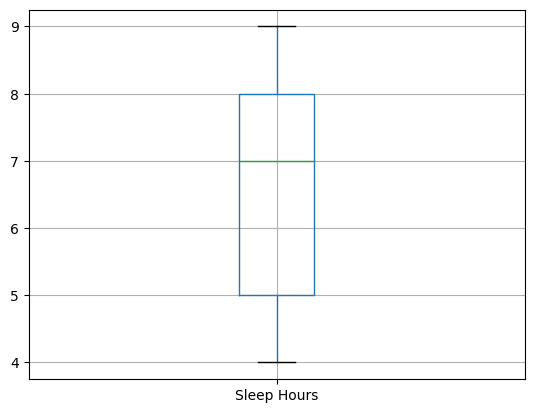

In [22]:
df.boxplot(column='Sleep Hours')

## 📊 4. Univariate Analysis
Menganalisis satu variabel (kolom) pada satu waktu untuk melihat distribusinya.
* **Tugas:** Buat **minimal 3 visualisasi** (misalnya *Histogram* atau *Bar Chart*) untuk 3 kolom yang berbeda.
* **Interpretasi:** Buat *Text Cell* di bawah kodemu dan tuliskan 1-2 kalimat kesimpulan dari masing-masing grafik (misal: "Sebagian besar siswa memiliki jam tidur di rentang X hingga Y jam").

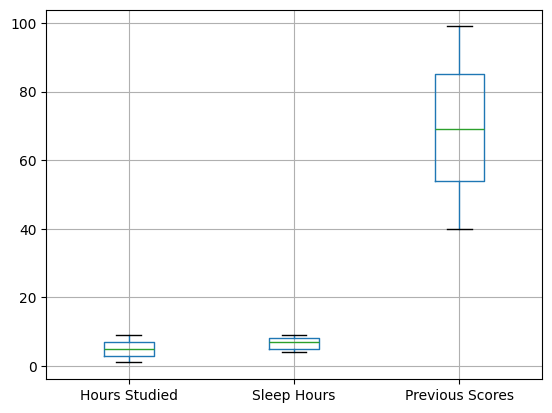

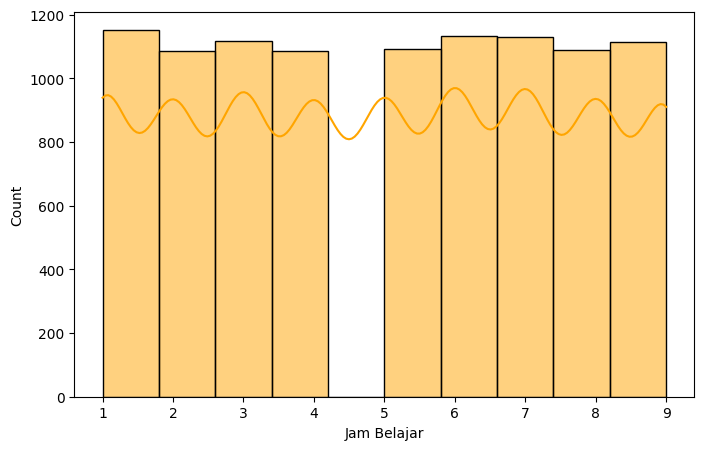

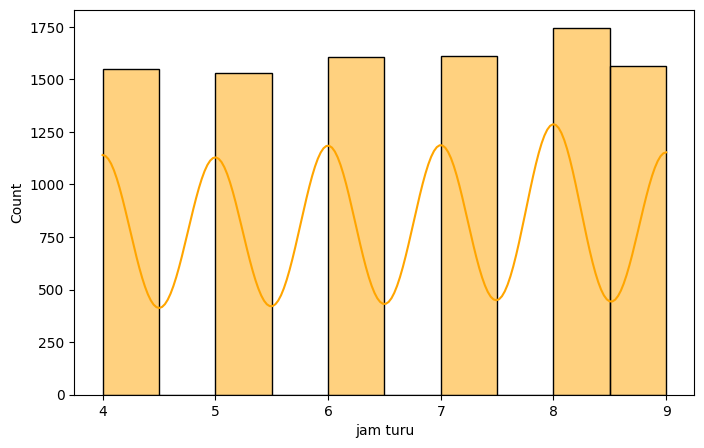

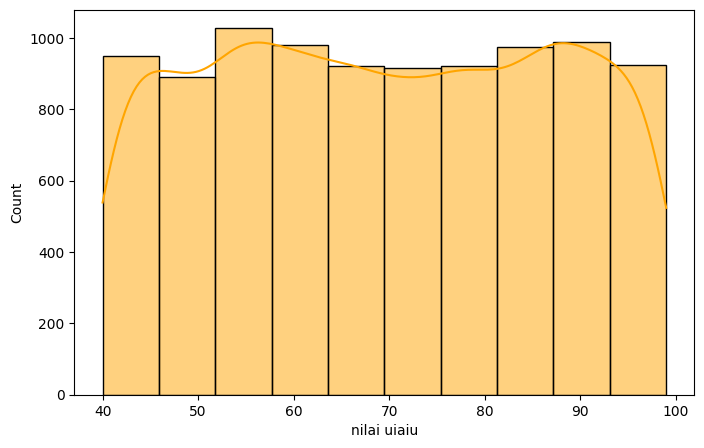

In [36]:
df.boxplot(column=['Hours Studied', 'Sleep Hours', 'Previous Scores'])


plt.figure(figsize=(8, 5))
sns.histplot(df['Hours Studied'], bins=10, kde=True, color='orange')
plt.xlabel('Jam Belajar')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['Sleep Hours'], bins=10, kde=True, color='orange')
plt.xlabel('jam turu')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['Previous Scores'], bins=10, kde=True, color='orange')
plt.xlabel('nilai uiaiu')
plt.show()

## 📈 5. Bivariate Analysis
Menganalisis hubungan antara dua variabel.
* **Tugas:** Buat **minimal 2 visualisasi** (misalnya *Scatter Plot* untuk numerik atau *Box Plot* untuk kategorikal (Pilih salah satu, keduanya lebih baik)) yang membandingkan dua kolom.
* **Interpretasi:** Buat *Text Cell* dan tuliskan kesimpulanmu. Apakah ada pola yang menarik antara dua variabel tersebut? (Misal: "Semakin tinggi jam belajar, nilai ujian cenderung semakin naik").

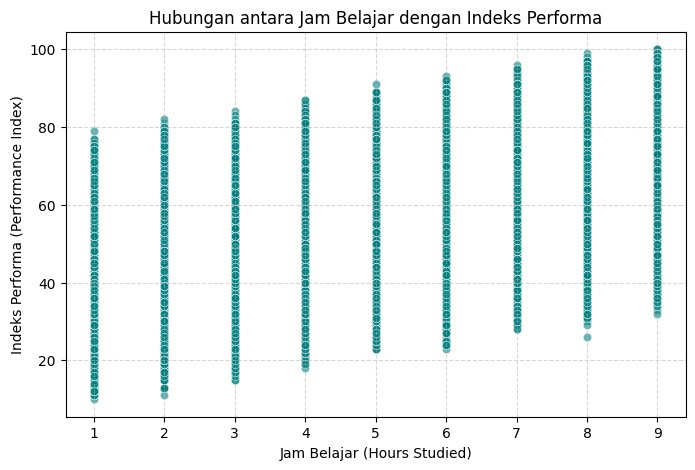

In [38]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Hours Studied', y='Performance Index', data=df, color='teal', alpha=0.6)
plt.title('Hubungan antara Jam Belajar dengan Indeks Performa')
plt.xlabel('Jam Belajar (Hours Studied)')
plt.ylabel('Indeks Performa (Performance Index)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

lama belajar berbanding lurus dengan performanya

## 🕸️ 6. Multivariate Analysis
Menganalisis hubungan lebih dari dua variabel sekaligus.
* **Tugas:** Buat **minimal 1 visualisasi** multivariate. (Saran: Buat *Correlation Heatmap* untuk melihat korelasi antar semua kolom numerik).
* **Interpretasi:** Tuliskan kesimpulanmu di *Text Cell*. Fitur mana yang paling kuat pengaruhnya terhadap target / variabel lain?

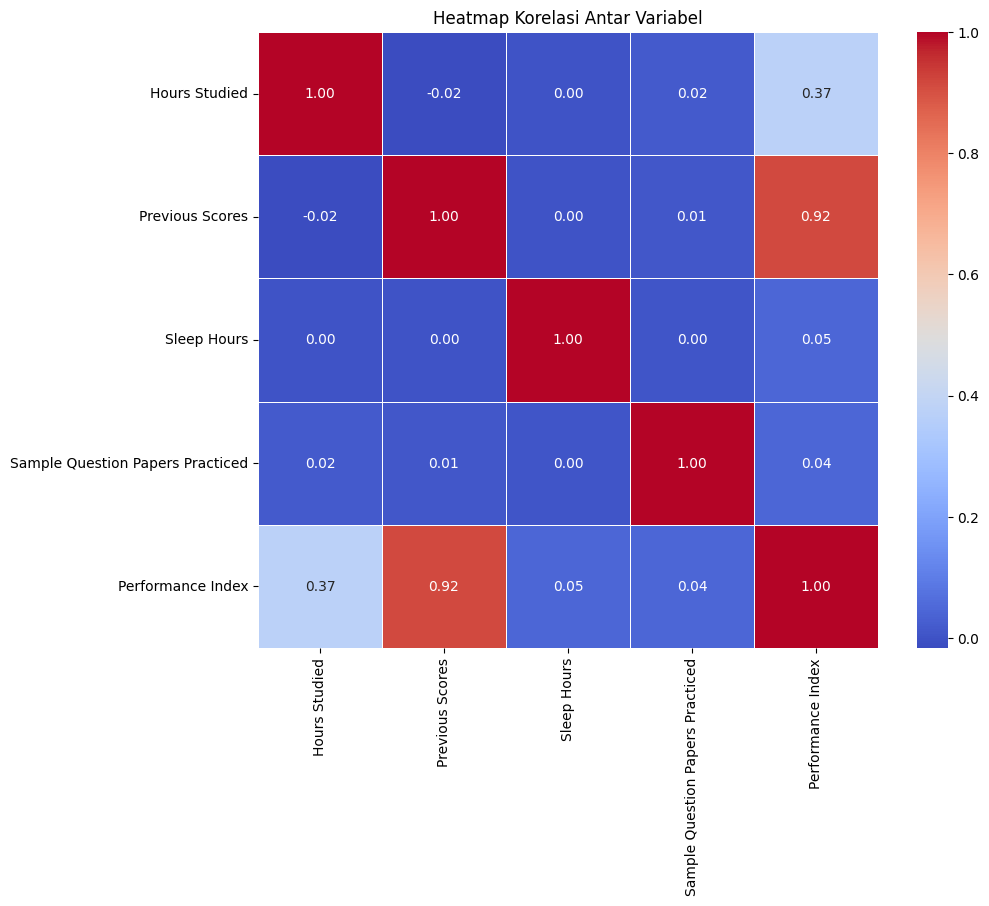

In [39]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

ini saya bingung jujur aja, kenapa angkanya kecil bet buset

### A. Handling Duplicates
* **Tugas:** Hapus data duplikat jika kamu menemukannya di Langkah 3. Tampilkan ukuran data (`df.shape`) sebelum dan sesudah penghapusan.

### B. Handling Missing Values
* **Tugas:** Isi atau hapus data yang kosong (Missing Values).
* **Catatan:** Tuliskan alasanmu di *Text Cell*. (Misal: "Saya mengisi kolom X dengan nilai Median karena datanya numerik dan terdapat outlier", atau "Saya mengisi kolom Y dengan Modus karena datanya kategorikal").

In [43]:
print("Ukuran sebelum:", df.shape)
df = df.drop_duplicates()
print("Ukuran sesudah:", df.shape)

Ukuran sebelum: (10000, 6)
Ukuran sesudah: (9901, 6)


In [54]:
print (df.isnull().sum())
df = df.dropna()


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64
